In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

print("Baseline forecasting environment initialized successfully.")

Baseline forecasting environment initialized successfully.


In [2]:
BASE_DIR = Path.cwd().parent
PROCESSED_DIR = BASE_DIR / "data" / "processed"

train = pd.read_csv(
    PROCESSED_DIR / "train_daily_demand.csv"
)

validation = pd.read_csv(
    PROCESSED_DIR / "validation_daily_demand.csv"
)

train["date"] = pd.to_datetime(train["date"])
validation["date"] = pd.to_datetime(validation["date"])

print("Training shape:", train.shape)
print("Validation shape:", validation.shape)

print("\nTraining period:")
print(train["date"].min(), "to", train["date"].max())

print("\nValidation period:")
print(validation["date"].min(), "to", validation["date"].max())

Training shape: (1913, 2)
Validation shape: (28, 2)

Training period:
2011-01-29 00:00:00 to 2016-04-24 00:00:00

Validation period:
2016-04-25 00:00:00 to 2016-05-22 00:00:00


In [3]:
last_train_value = train["units_sold"].iloc[-1]

naive_forecast = np.repeat(
    last_train_value,
    len(validation)
)

print("Last training demand:", last_train_value)
print("Naive forecast:")
print(naive_forecast)

Last training demand: 49795
Naive forecast:
[49795 49795 49795 49795 49795 49795 49795 49795 49795 49795 49795 49795
 49795 49795 49795 49795 49795 49795 49795 49795 49795 49795 49795 49795
 49795 49795 49795 49795]


In [4]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

actual = validation["units_sold"].values

naive_mae = mean_absolute_error(
    actual,
    naive_forecast
)

naive_rmse = np.sqrt(
    mean_squared_error(
        actual,
        naive_forecast
    )
)

naive_mape = np.mean(
    np.abs(
        (actual - naive_forecast) /
        np.where(actual == 0, 1, actual)
    )
) * 100

print("NAIVE FORECAST RESULTS")
print("=" * 40)
print("MAE :", naive_mae)
print("RMSE:", naive_rmse)
print("MAPE:", naive_mape, "%")

NAIVE FORECAST RESULTS
MAE : 7890.571428571428
RMSE: 8817.170059443271
MAPE: 19.395964155973598 %


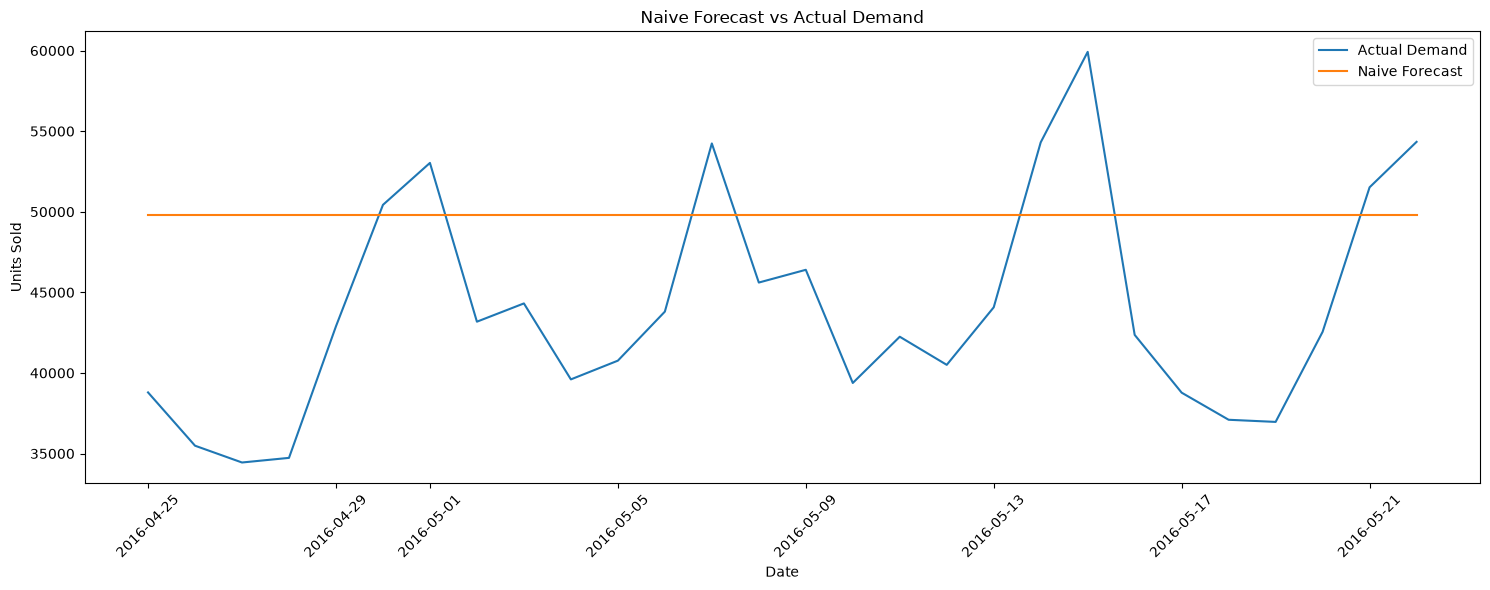

In [5]:
plt.figure(figsize=(15, 6))

plt.plot(
    validation["date"],
    actual,
    label="Actual Demand"
)

plt.plot(
    validation["date"],
    naive_forecast,
    label="Naive Forecast"
)

plt.title("Naive Forecast vs Actual Demand")
plt.xlabel("Date")
plt.ylabel("Units Sold")

plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [6]:
last_7_days = train["units_sold"].tail(7)

moving_average_value = last_7_days.mean()

moving_average_forecast = np.repeat(
    moving_average_value,
    len(validation)
)

print("Last 7 days:")
print(last_7_days.values)

print("\n7-day average demand:",
      moving_average_value)

Last 7 days:
[38059 37570 35343 35033 40517 48962 49795]

7-day average demand: 40754.142857142855


In [7]:
moving_average_mae = mean_absolute_error(
    actual,
    moving_average_forecast
)

moving_average_rmse = np.sqrt(
    mean_squared_error(
        actual,
        moving_average_forecast
    )
)

moving_average_mape = np.mean(
    np.abs(
        (actual - moving_average_forecast) /
        np.where(actual == 0, 1, actual)
    )
) * 100

print("7-DAY MOVING AVERAGE RESULTS")
print("=" * 40)
print("MAE :", moving_average_mae)
print("RMSE:", moving_average_rmse)
print("MAPE:", moving_average_mape, "%")

7-DAY MOVING AVERAGE RESULTS
MAE : 5506.387755102041
RMSE: 7385.367183056739
MAPE: 11.620050810754464 %


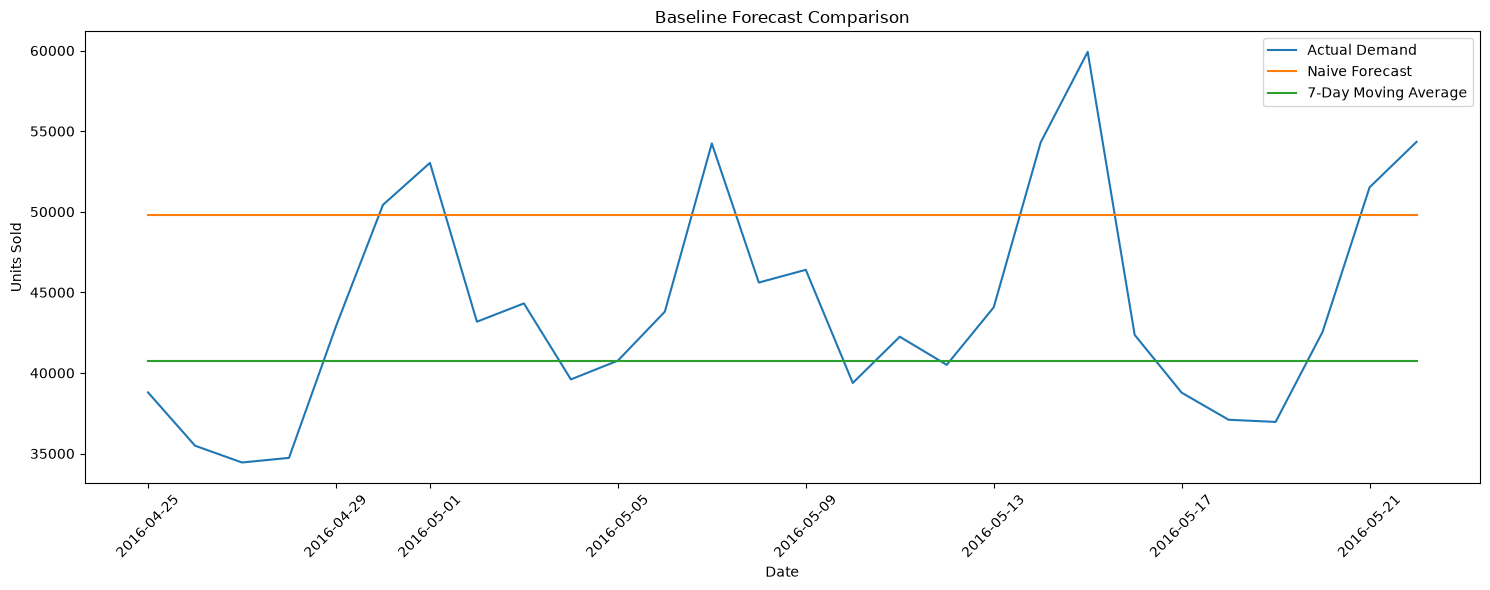

In [8]:
plt.figure(figsize=(15, 6))

plt.plot(
    validation["date"],
    actual,
    label="Actual Demand"
)

plt.plot(
    validation["date"],
    naive_forecast,
    label="Naive Forecast"
)

plt.plot(
    validation["date"],
    moving_average_forecast,
    label="7-Day Moving Average"
)

plt.title("Baseline Forecast Comparison")
plt.xlabel("Date")
plt.ylabel("Units Sold")

plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [12]:
baseline_results = pd.DataFrame({
    "Model": [
        "Naive Forecast",
        "7-Day Moving Average"
    ],
    "MAE": [
        naive_mae,
        moving_average_mae
    ],
    "RMSE": [
        naive_rmse,
        moving_average_rmse
    ],
    "MAPE": [
        naive_mape,
        moving_average_mape
    ]
})

print("Baseline results created successfully.")
print(baseline_results)

Baseline results created successfully.
                  Model          MAE         RMSE       MAPE
0        Naive Forecast  7890.571429  8817.170059  19.395964
1  7-Day Moving Average  5506.387755  7385.367183  11.620051


In [13]:
RESULTS_DIR = BASE_DIR / "reports" / "model_results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

baseline_results.to_csv(
    RESULTS_DIR / "baseline_results.csv",
    index=False
)

print("Baseline results saved successfully.")
print(RESULTS_DIR / "baseline_results.csv")

Baseline results saved successfully.
c:\Users\DELL-PC\Desktop\retail-demand-forecasting\reports\model_results\baseline_results.csv
